# OSRS money makers — top earners over time

Dataset: [nicapotato/osrs-money-makers](https://www.kaggle.com/datasets/nicapotato/osrs-money-makers) (`methods.parquet`, `input_output.parquet`, partitioned `snapshots/` and `prices/`).

**Grain:** one row per **method × calendar day** after collapsing intraday wiki scrapes. Snapshot fields include `rank`, `hourly_profit_gp`, `gp_per_completion`, and `completions_per_hour`. GE price partitions track `price`, `volume`, quartiles, and `price_variance` per `item_id`.

**Objective:** identify which money-making methods **lead the leaderboard**, how **hourly profit and rank shift** day-over-day by **money-maker type** (Skilling, Combat/PvM, Processing, Collecting), compare **raid input cost vs output value**, and explore linked **GE item prices** interactively.

- **Plotly on Kaggle**: iframe renderer via `show_plotly` (same pattern as other notebooks in this folder).


In [1]:
from pathlib import Path
import os
import textwrap

import kagglehub
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import seaborn as sns
from IPython.display import display, HTML
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.figsize": (11, 5),
        "legend.fontsize": 10,
    }
)

PRISM = list(px.colors.qualitative.Prism)
px.defaults.template = "plotly_white"
px.defaults.color_discrete_sequence = PRISM

_IS_KAGGLE = bool(os.environ.get("KAGGLE_KERNEL_RUN_TYPE")) or Path("/kaggle").exists()
if _IS_KAGGLE:
    pio.renderers.default = "iframe"


def show_plotly(fig):
    fig.update_layout(paper_bgcolor="white", plot_bgcolor="white", colorway=PRISM)
    if os.environ.get("PLOTLY_FORCE_HTML", "").lower() in ("1", "true", "yes"):
        display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False)))
    elif _IS_KAGGLE:
        fig.show()
    else:
        display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False)))


DATA_SLUG = "nicapotato/osrs-money-makers"
METHODS_FILE = "methods.parquet"
IO_FILE = "input_output.parquet"
SNAPSHOTS_DIR = "snapshots"
PRICES_DIR = "prices"
TOP_TRAJECTORIES = 20
TOP_TABLE = 12
TOP_RANK_BOARD = 20
FACET_COL_WRAP = 3
TITLE_WRAP_WIDTH = 28
X_DATE_MAX_TICKS = 6

RAID_NAME_PATTERN = (
    r"Chambers of Xeric|Theatre of Blood|Tombs of Amascut|"
    r"Fortis Colosseum|Nightmare|Phosani|Moons of Peril|"
    r"Corrupted Gauntlet|The Gauntlet"
)


In [2]:
SNAPSHOT_REQUIRED_COLS = {
    "method_id",
    "year",
    "month",
    "day",
    "rank",
    "hourly_profit_gp",
    "gp_per_completion",
    "completions_per_hour",
}
METHOD_REQUIRED_COLS = {"method_id", "method_name", "categories", "intensity", "is_members"}
IO_REQUIRED_COLS = {"line_id", "method_id", "io_type", "item_id", "item_name", "qty_per_completion"}
PRICE_METRICS = {"price", "volume", "price_p25", "price_p50", "price_p75", "price_variance"}


def read_snapshot_parquets(paths: list[Path]) -> pd.DataFrame:
    assert paths, "no snapshot parquet files"
    df = pd.concat([pd.read_parquet(p) for p in paths], ignore_index=True)
    missing = SNAPSHOT_REQUIRED_COLS - set(df.columns)
    assert not missing, f"snapshot schema missing columns: {sorted(missing)}"
    return df


def resolve_dataset_root() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        matches = sorted(kaggle_root.rglob(METHODS_FILE))
        assert matches, f"no {METHODS_FILE} under {kaggle_root}"
        return matches[0].parent

    # Always pull the latest dataset version locally (Kaggle scrapes update daily).
    # Local: kagglehub resolves the latest dataset version (re-downloads when a newer version exists).
    root = Path(kagglehub.dataset_download(DATA_SLUG))
    print("Path to dataset files:", root)
    return root


def load_parquet_file(root: Path, file_path: str, required_cols: set[str]) -> pd.DataFrame:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        matches = sorted(
            kaggle_root.rglob(file_path),
            key=lambda p: p.stat().st_size,
            reverse=True,
        )
        assert matches, f"no {file_path} under {kaggle_root}"
        print(f"Kaggle input: {matches[0]}")
        df = pd.read_parquet(matches[0])
    else:
        candidate = root / file_path
        assert candidate.exists(), f"expected {file_path} under {root}"
        print(f"Dataset file: {candidate.resolve()}")
        df = pd.read_parquet(candidate)
    missing = required_cols - set(df.columns)
    assert not missing, f"{file_path} missing columns: {sorted(missing)}"
    return df


def load_snapshots(root: Path) -> pd.DataFrame:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        paths = sorted(kaggle_root.rglob(f"{SNAPSHOTS_DIR}/**/*.parquet"))
        assert paths, f"no snapshot parquet under {kaggle_root}/{SNAPSHOTS_DIR}"
        print(f"Kaggle snapshots: {len(paths)} partition file(s)")
        return read_snapshot_parquets(paths)

    paths = sorted((root / SNAPSHOTS_DIR).rglob("*.parquet"))
    assert paths, f"no snapshot parquet under {root}/{SNAPSHOTS_DIR}"
    print(f"Snapshots: {len(paths)} partition file(s) from {root}")
    return read_snapshot_parquets(paths)


def load_prices_for_dates(root: Path, snapshot_dates: pd.Series) -> pd.DataFrame:
    frames: list[pd.DataFrame] = []
    for dt in sorted(snapshot_dates.unique()):
        partition = (
            root
            / PRICES_DIR
            / f"year={int(dt.year)}"
            / f"month={int(dt.month):02d}"
            / f"day={int(dt.day):02d}"
            / "part-0.parquet"
        )
        assert partition.exists(), f"missing price partition for {dt.date()}: {partition}"
        frames.append(pd.read_parquet(partition))
    prices = pd.concat(frames, ignore_index=True)
    unknown_metrics = set(prices["metric"].unique()) - PRICE_METRICS
    assert not unknown_metrics, f"unexpected price metrics: {sorted(unknown_metrics)}"
    prices["snapshot_date"] = pd.to_datetime(
        dict(year=prices["year"], month=prices["month"], day=prices["day"])
    )
    return prices


def primary_category(categories) -> str:
    if isinstance(categories, (list, tuple, np.ndarray)) and len(categories):
        return str(categories[0])
    return "Unknown"


def secondary_category(categories) -> str:
    if isinstance(categories, (list, tuple, np.ndarray)) and len(categories) > 1:
        return str(categories[1])
    return "—"


def wrap_facet_title(name: str, width: int = TITLE_WRAP_WIDTH) -> str:
    return "\n".join(textwrap.wrap(str(name), width=width, break_long_words=False)[:2])


def style_facet_dates(g, max_ticks: int = X_DATE_MAX_TICKS):
    locator = mdates.AutoDateLocator(minticks=3, maxticks=max_ticks)
    formatter = mdates.ConciseDateFormatter(locator)
    for ax in g.axes.flat:
        if ax.has_data():
            ax.xaxis.set_major_locator(locator)
            ax.xaxis.set_major_formatter(formatter)
            ax.tick_params(axis="x", rotation=45, labelsize=8)
            ax.set_title(ax.get_title(), fontsize=9)


dataset_root = resolve_dataset_root()
methods = load_parquet_file(dataset_root, METHODS_FILE, METHOD_REQUIRED_COLS)
io_lines = load_parquet_file(dataset_root, IO_FILE, IO_REQUIRED_COLS)
snapshots = load_snapshots(dataset_root)

assert snapshots[["year", "month", "day"]].notna().all().all()
snapshots["snapshot_date"] = pd.to_datetime(
    dict(year=snapshots["year"], month=snapshots["month"], day=snapshots["day"])
)

daily = (
    snapshots.groupby(["method_id", "snapshot_date", "year", "month", "day"], as_index=False)
    .agg(
        rank=("rank", "min"),
        hourly_profit_gp=("hourly_profit_gp", "max"),
        gp_per_completion=("gp_per_completion", "max"),
        completions_per_hour=("completions_per_hour", "max"),
        scrape_timestamp=("scrape_timestamp", "max"),
    )
    .sort_values(["method_id", "snapshot_date"])
    .reset_index(drop=True)
)

panel = daily.merge(methods, on="method_id", how="left", validate="m:1")
assert panel["method_name"].notna().all(), "snapshot method_id missing from methods table"
panel["primary_category"] = panel["categories"].map(primary_category)
panel["secondary_category"] = panel["categories"].map(secondary_category)
panel["money_maker_type"] = panel["primary_category"].replace({"Combat": "Combat / PvM"})
panel["hourly_profit_m"] = panel["hourly_profit_gp"] / 1_000_000
panel["hourly_profit_delta"] = panel.groupby("method_id")["hourly_profit_gp"].diff()
panel["rank_delta"] = panel.groupby("method_id")["rank"].diff()
panel["rank_improvement"] = -panel["rank_delta"]
panel["gp_per_completion_delta"] = panel.groupby("method_id")["gp_per_completion"].diff()
panel["completions_per_hour_delta"] = panel.groupby("method_id")["completions_per_hour"].diff()
panel["day_index"] = panel.groupby("method_id").cumcount() + 1
panel["days_seen"] = panel.groupby("method_id")["method_id"].transform("count")

transitions = panel.loc[panel["hourly_profit_delta"].notna()].copy()
prices = load_prices_for_dates(dataset_root, panel["snapshot_date"])

print("Methods:", methods.shape[0], "rows ×", methods.shape[1], "cols")
print("Input/output lines:", io_lines.shape[0], "rows ×", io_lines.shape[1], "cols")
print("Raw snapshots:", snapshots.shape[0], "rows ×", snapshots.shape[1], "cols")
print("Daily panel:", panel.shape[0], "rows ×", panel.shape[1], "cols")
print("Price rows (snapshot window):", prices.shape[0], "rows ×", prices.shape[1], "cols")
print(
    "Snapshot dates:",
    panel["snapshot_date"].min().date(),
    "→",
    panel["snapshot_date"].max().date(),
    f"({panel['snapshot_date'].nunique()} days)",
)
print("Methods seen on 2+ days:", int((panel.groupby("method_id").size() >= 2).sum()))
print("Money-maker types:", ", ".join(sorted(panel["money_maker_type"].unique())))
display(panel.sample(5, random_state=42))


Kaggle input: /kaggle/input/datasets/nicapotato/osrs-money-makers/methods.parquet
Kaggle input: /kaggle/input/datasets/nicapotato/osrs-money-makers/input_output.parquet
Kaggle snapshots: 30 partition file(s)
Methods: 520 rows × 6 cols
Input/output lines: 6362 rows × 8 cols
Raw snapshots: 14634 rows × 11 cols
Daily panel: 14634 rows × 26 cols
Price rows (snapshot window): 183234 rows × 8 cols
Snapshot dates: 2026-05-22 → 2026-08-10 (30 days)
Methods seen on 2+ days: 520
Money-maker types: Collecting, Combat / PvM, Ironman, Processing, Skilling


,method_id,snapshot_date,year,month,day,rank,hourly_profit_gp,gp_per_completion,completions_per_hour,scrape_timestamp,...,secondary_category,money_maker_type,hourly_profit_m,hourly_profit_delta,rank_delta,rank_improvement,gp_per_completion_delta,completions_per_hour_delta,day_index,days_seen
2360,269937076d2ce951,2026-06-08,2026,6,8,488,18000,1.824000e+04,120.0,2026-06-08 06:01:10.161192+00:00,...,Mining,Skilling,0.018,0.0,3.0,-3.0,-120.000000,0.0,18,30
6561,752119605be7b16f,2026-05-30,2026,5,30,416,113000,1.128000e+05,2400.0,2026-05-30 06:01:46.686196+00:00,...,—,Processing,0.113,17000.0,-16.0,16.0,16800.000000,0.0,9,30
12170,d8c397aaa7bee5bb,2026-05-25,2026,5,25,405,142000,1.418250e+05,775.0,2026-05-25 06:01:41.496800+00:00,...,Smithing,Skilling,0.142,0.0,0.0,-0.0,0.000000,0.0,4,30
8874,a22c07ef80cee81c,2026-05-24,2026,5,24,129,1107000,1.107156e+06,24.0,2026-05-24 17:11:59.645284+00:00,...,High,Combat / PvM,1.107,-6000.0,-2.0,2.0,-6037.111549,0.0,3,30
12955,e70672481f45f6ad,2026-06-11,2026,6,11,315,291000,2.906976e+05,90.0,2026-06-11 06:01:07.435476+00:00,...,Mining,Skilling,0.291,-2000.0,0.0,-0.0,-2540.272500,0.0,21,30


## 1 — Table shape, dtypes, and daily coverage

,dtype
method_id,object
snapshot_date,datetime64[ns]
year,uint16
month,uint8
day,uint8
rank,uint16
hourly_profit_gp,uint32
gp_per_completion,float64
completions_per_hour,float64
scrape_timestamp,"datetime64[us, UTC]"


,count,mean,std,min,25%,50%,75%,max
rank,14634.0,2.444084e+02,1.408348e+02,1.0,122.0,244.000000,366.0,4.930000e+02
hourly_profit_gp,14634.0,1.226416e+06,2.070531e+06,15000.0,205000.0,524000.000000,1240000.0,1.741200e+07
gp_per_completion,14634.0,1.225811e+06,2.069050e+06,-81000.0,204985.0,522660.058594,1239532.0,1.741243e+07
completions_per_hour,14496.0,1.172030e+03,2.388575e+03,1.0,60.0,308.000000,1200.0,2.700000e+04
hourly_profit_delta,14114.0,-2.196401e+02,2.001487e+05,-9272000.0,-2000.0,0.000000,2000.0,5.665000e+06
rank_delta,14114.0,1.448207e-01,1.925586e+01,-235.0,-1.0,0.000000,2.0,3.230000e+02
days_seen,14634.0,2.921184e+01,3.189491e+00,2.0,30.0,30.000000,30.0,3.000000e+01


Daily scrape coverage:


,snapshot_date,methods,median_hourly_profit,p90_hourly_profit,top_method_profit
0,2026-05-22,489,515000.0,2815000.0,17091000
1,2026-05-23,489,515000.0,2815000.0,17091000
2,2026-05-24,488,511000.0,2873900.0,17219000
3,2026-05-25,488,511000.0,2873900.0,17219000
4,2026-05-26,487,524000.0,2772000.0,17412000
5,2026-05-27,487,524000.0,2772000.0,17412000
6,2026-05-28,488,512000.0,2841100.0,16979000
7,2026-05-29,488,512000.0,2861900.0,16986000
8,2026-05-30,485,507000.0,2890000.0,16780000
9,2026-05-31,482,519000.0,2892800.0,17061000


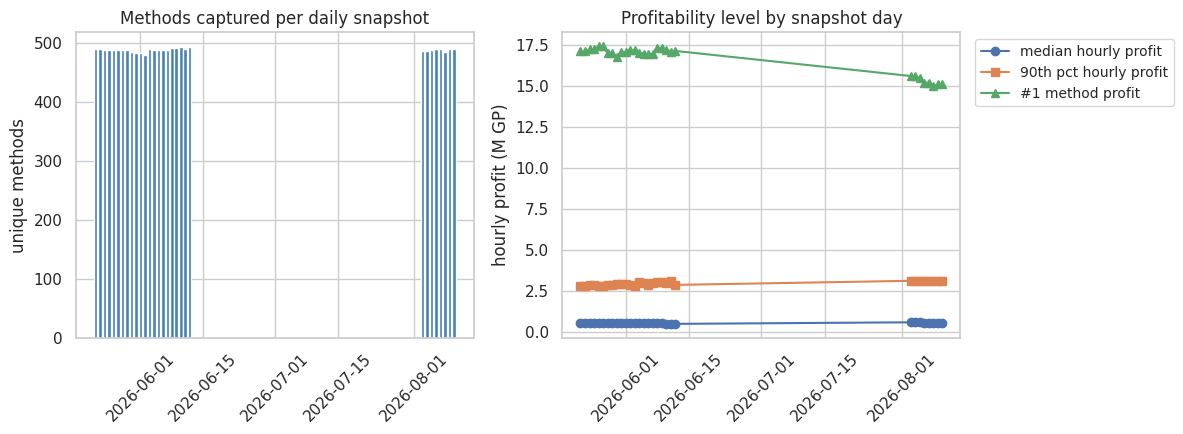

In [3]:
display(panel.dtypes.to_frame("dtype"))
display(
    panel[
        [
            "rank",
            "hourly_profit_gp",
            "gp_per_completion",
            "completions_per_hour",
            "hourly_profit_delta",
            "rank_delta",
            "days_seen",
        ]
    ].describe().T
)

daily_coverage = (
    panel.groupby("snapshot_date", as_index=False)
    .agg(
        methods=("method_id", "nunique"),
        median_hourly_profit=("hourly_profit_gp", "median"),
        p90_hourly_profit=("hourly_profit_gp", lambda s: s.quantile(0.9)),
        top_method_profit=("hourly_profit_gp", "max"),
    )
    .sort_values("snapshot_date")
)
print("Daily scrape coverage:")
display(daily_coverage)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(daily_coverage["snapshot_date"], daily_coverage["methods"], color="steelblue")
axes[0].set_title("Methods captured per daily snapshot")
axes[0].set_ylabel("unique methods")
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(
    daily_coverage["snapshot_date"],
    daily_coverage["median_hourly_profit"] / 1_000_000,
    marker="o",
    label="median hourly profit",
)
axes[1].plot(
    daily_coverage["snapshot_date"],
    daily_coverage["p90_hourly_profit"] / 1_000_000,
    marker="s",
    label="90th pct hourly profit",
)
axes[1].plot(
    daily_coverage["snapshot_date"],
    daily_coverage["top_method_profit"] / 1_000_000,
    marker="^",
    label="#1 method profit",
)
axes[1].set_title("Profitability level by snapshot day")
axes[1].set_ylabel("hourly profit (M GP)")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1].tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

### Univariate readout

The wiki scrape tracks roughly **500** money-making methods each day. Leaderboard rank is wiki-assigned (lower = more profitable). Day-over-day transitions below use only methods that appear on **consecutive** snapshot dates.

## 2 — Univariate: persistence, profit spread, and rank mobility

How long methods stay in the daily scrape:


,days_seen,methods
0,2,1
1,3,3
2,4,2
3,5,1
4,7,1
5,8,14
6,9,2
7,11,2
8,14,2
9,16,3


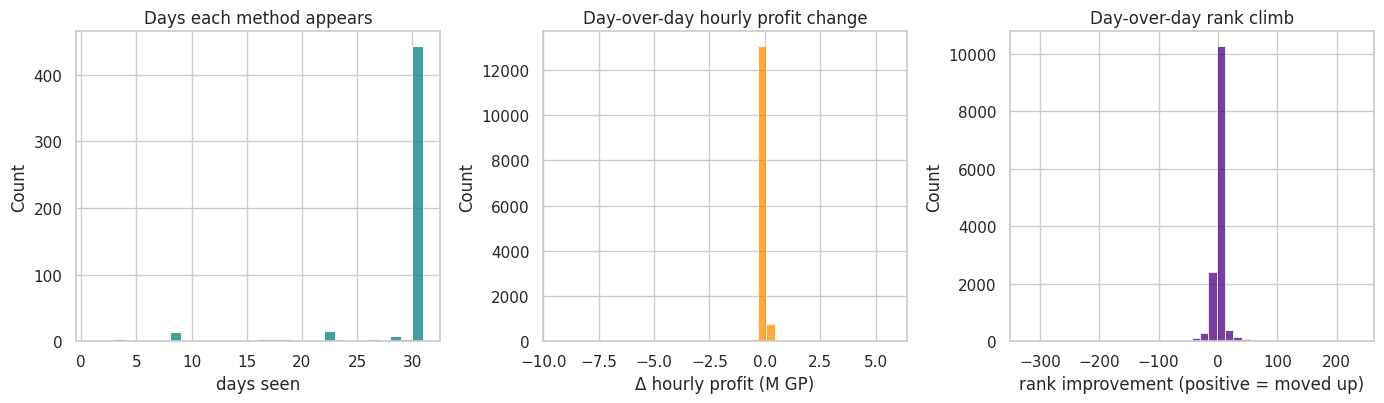

Single-day hourly profit change tiers (day-over-day transitions):
hourly_profit_delta
−500k–0      9850
0–500k       4045
≤−500k        110
500k–1.5M      87
1.5M+          22


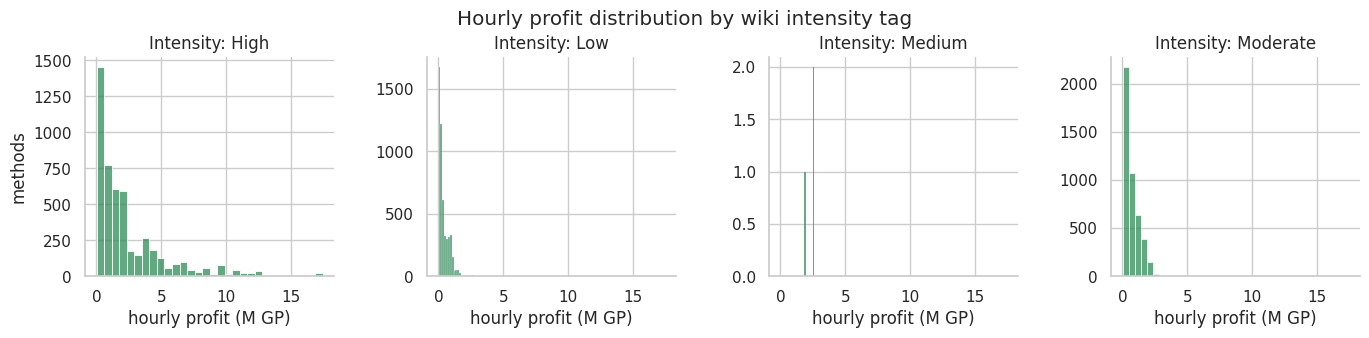

In [4]:
days_on_board = panel.groupby("method_id").size()
persistence = days_on_board.value_counts().sort_index().rename_axis("days_seen").reset_index(name="methods")
print("How long methods stay in the daily scrape:")
display(persistence.head(10))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
sns.histplot(days_on_board, bins=range(1, int(days_on_board.max()) + 2), ax=axes[0], color="teal")
axes[0].set_title("Days each method appears")
axes[0].set_xlabel("days seen")

sns.histplot(
    transitions["hourly_profit_delta"].dropna() / 1_000_000,
    bins=40,
    ax=axes[1],
    color="darkorange",
)
axes[1].set_title("Day-over-day hourly profit change")
axes[1].set_xlabel("Δ hourly profit (M GP)")

sns.histplot(transitions["rank_improvement"].dropna(), bins=40, ax=axes[2], color="indigo")
axes[2].set_title("Day-over-day rank climb")
axes[2].set_xlabel("rank improvement (positive = moved up)")
fig.tight_layout()
plt.show()

profit_tiers = pd.cut(
    transitions["hourly_profit_delta"],
    bins=[-np.inf, -500_000, 0, 500_000, 1_500_000, np.inf],
    labels=["≤−500k", "−500k–0", "0–500k", "500k–1.5M", "1.5M+"],
)
print("Single-day hourly profit change tiers (day-over-day transitions):")
print(profit_tiers.value_counts().to_string())

g = sns.FacetGrid(
    panel,
    col="intensity",
    col_order=sorted(panel["intensity"].unique()),
    height=3.3,
    aspect=1.05,
    sharex=True,
    sharey=False,
)
g.map_dataframe(sns.histplot, x="hourly_profit_m", bins=30, color="seagreen")
g.set_axis_labels("hourly profit (M GP)", "methods")
g.set_titles(col_template="Intensity: {col_name}")
g.fig.suptitle("Hourly profit distribution by wiki intensity tag", y=1.02)
plt.show()

## 3 — Multivariate: leaderboard, trajectories, and category patterns


Top 20 methods on 2026-08-10 (wiki rank):


,method_id,rank,method_name,money_maker_type,secondary_category,intensity,hourly_profit_gp,gp_per_completion,completions_per_hour,is_members
0,d0a256b15104f393,1,Killing the Doom of Mokhaiotl (Delve 1-16),Combat / PvM,High,High,"15,078,000","15,077,627",2.5,True
1,3a628916d03de1b0,2,"Killing Yama (Contract of shard acquisition, duo)",Combat / PvM,High,High,"13,530,000","13,529,534",11.0,True
2,d5fb2972cd6709e1,3,Completing the Fortis Colosseum (Wave 12),Combat / PvM,High,High,"11,552,000","11,551,548",2.5,True
3,fe11525a467c2c96,4,Killing the Maggot King,Combat / PvM,High,High,"11,549,000","11,549,120",25.0,True
4,28e8a3206207cf16,5,Killing Phosani's Nightmare,Combat / PvM,High,High,"11,472,000","11,472,312",9.5,True
5,44dd5c6cd8c9e556,6,Killing The Doom of Mokhaiotl (Delve 1-8),Combat / PvM,High,High,"11,315,000","11,314,965",6.0,True
6,b0135e283e71183b,7,Killing Nex (Duo),Combat / PvM,High,High,"10,163,000","10,162,532",6.0,True
7,461163ca4c2f5446,8,Killing the Maggot King (Ranged),Combat / PvM,High,High,"9,942,000","9,942,375",20.0,True
8,aaa2106d27bd8695,9,Killing Duke Sucellus,Combat / PvM,High,High,"9,208,000","9,207,789",34.0,True
9,0ca79fb1ab95cb3b,10,Theatre of Blood,Combat / PvM,High,High,"9,196,000","9,195,633",3.0,True


Top 12 single-day hourly profit surges:


,snapshot_date,method_name,money_maker_type,rank,hourly_profit_gp,hourly_profit_delta,rank_improvement,gp_per_completion_delta
0,2026-06-08 00:00:00,Smithing oathplate armour,Skilling,2,"13,977,000","+5,665,000",11.000000,"+5,665,168"
1,2026-06-06 00:00:00,Smithing oathplate armour,Skilling,7,"9,815,000","+4,592,000",16.000000,"+4,592,268"
2,2026-06-10 00:00:00,Fletching gem-tipped dragon bolts,Skilling,26,"4,833,000","+3,510,000",97.000000,+0
3,2026-08-06 00:00:00,Creating crystal keys,Processing,26,"4,895,000","+3,245,000",70.000000,"+3,245,000"
4,2026-05-29 00:00:00,Creating crystal keys,Processing,34,"4,225,000","+3,040,000",92.000000,"+3,040,000"
5,2026-08-03 00:00:00,Poisoning ammunition,Processing,32,"4,259,000","+2,812,000",78.000000,"+2,812,000"
6,2026-08-09 00:00:00,Poisoning ammunition,Processing,31,"4,374,000","+2,790,000",70.000000,"+2,790,000"
7,2026-05-24 00:00:00,Crafting aether runes using scarred extract,Skilling,30,"4,717,000","+2,749,000",43.000000,"+2,749,507"
8,2026-05-30 00:00:00,Smithing oathplate armour,Skilling,10,"8,752,000","+2,619,000",8.000000,"+2,619,308"
9,2026-06-03 00:00:00,Killing Phosani's Nightmare,Combat / PvM,9,"9,606,000","+2,406,000",5.000000,"+2,406,412"


Top 12 cumulative hourly profit gain across tracked days:


,method_name,money_maker_type,days_seen,first_hourly_profit,last_hourly_profit,total_profit_gain,best_rank,max_single_day_gain
14,Forging Giant swords,Skilling,30,"172,000","171,000","+4,294,966,296",377,"+7,000"
83,Mining gold ore (free-to-play),Skilling,30,"18,000","17,000","+4,294,966,296",477,"+1,000"
197,Picking potatoes,Collecting,3,"16,000","15,000","+4,294,966,296",487,+0
237,Killing Zamorak monks,Combat / PvM,30,"23,000","22,000","+4,294,966,296",470,"+1,000"
372,Collecting red spiders' eggs (free-to-play),Collecting,30,"60,000","59,000","+4,294,966,296",441,"+3,000"
395,Crafting sapphire jewellery,Skilling,30,"175,000","174,000","+4,294,966,296",351,"+61,000"
410,Killing ankou,Combat / PvM,8,"141,000","140,000","+4,294,966,296",410,"+1,000"
452,Crafting air runes (high level),Skilling,30,"770,000","769,000","+4,294,966,296",166,"+163,000"
485,Making dough at Cooks' Guild,Processing,30,"43,000","42,000","+4,294,966,296",452,"+3,000"
1,Mining gold ore (Crafting Guild),Skilling,30,"32,000","30,000","+4,294,965,296",461,"+1,000"


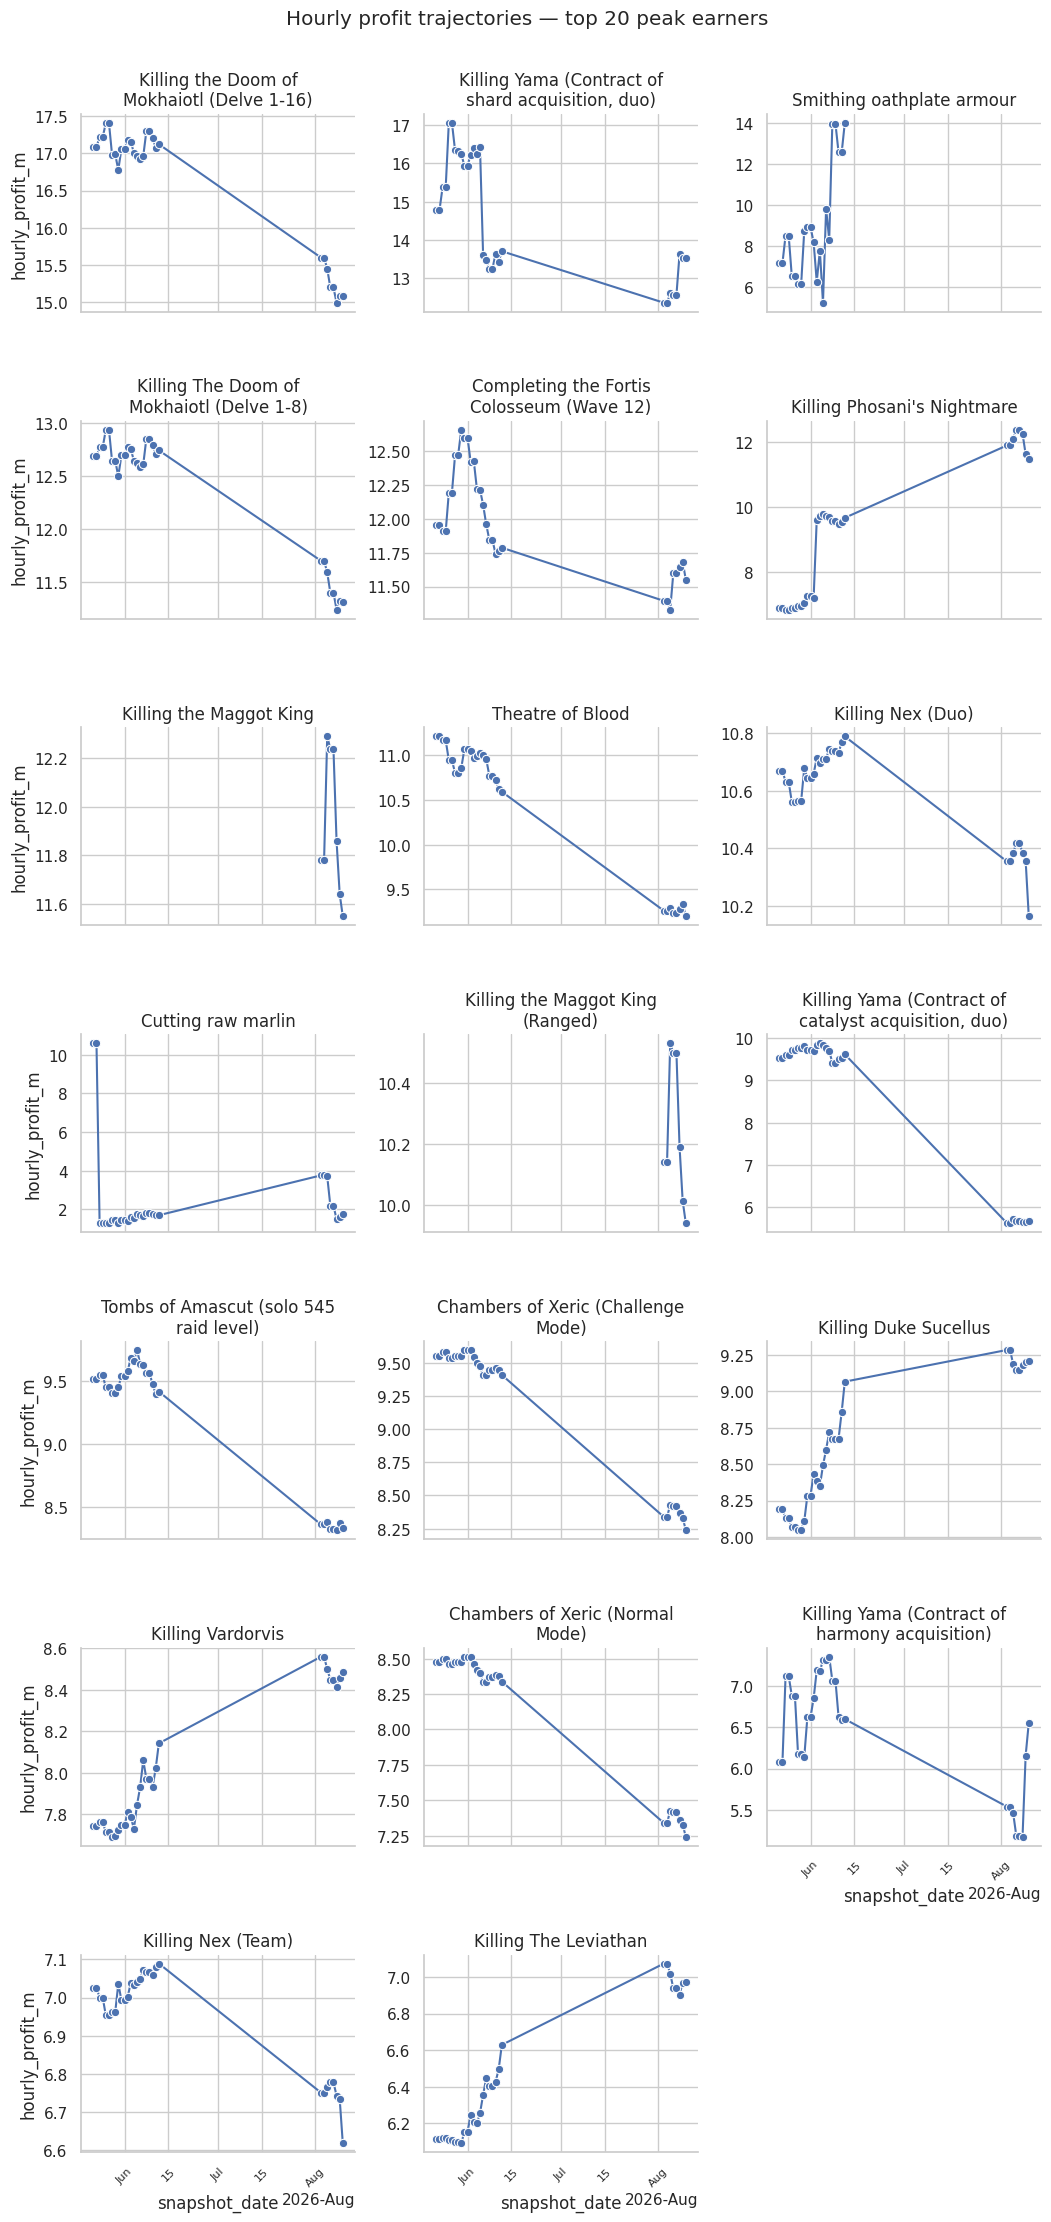

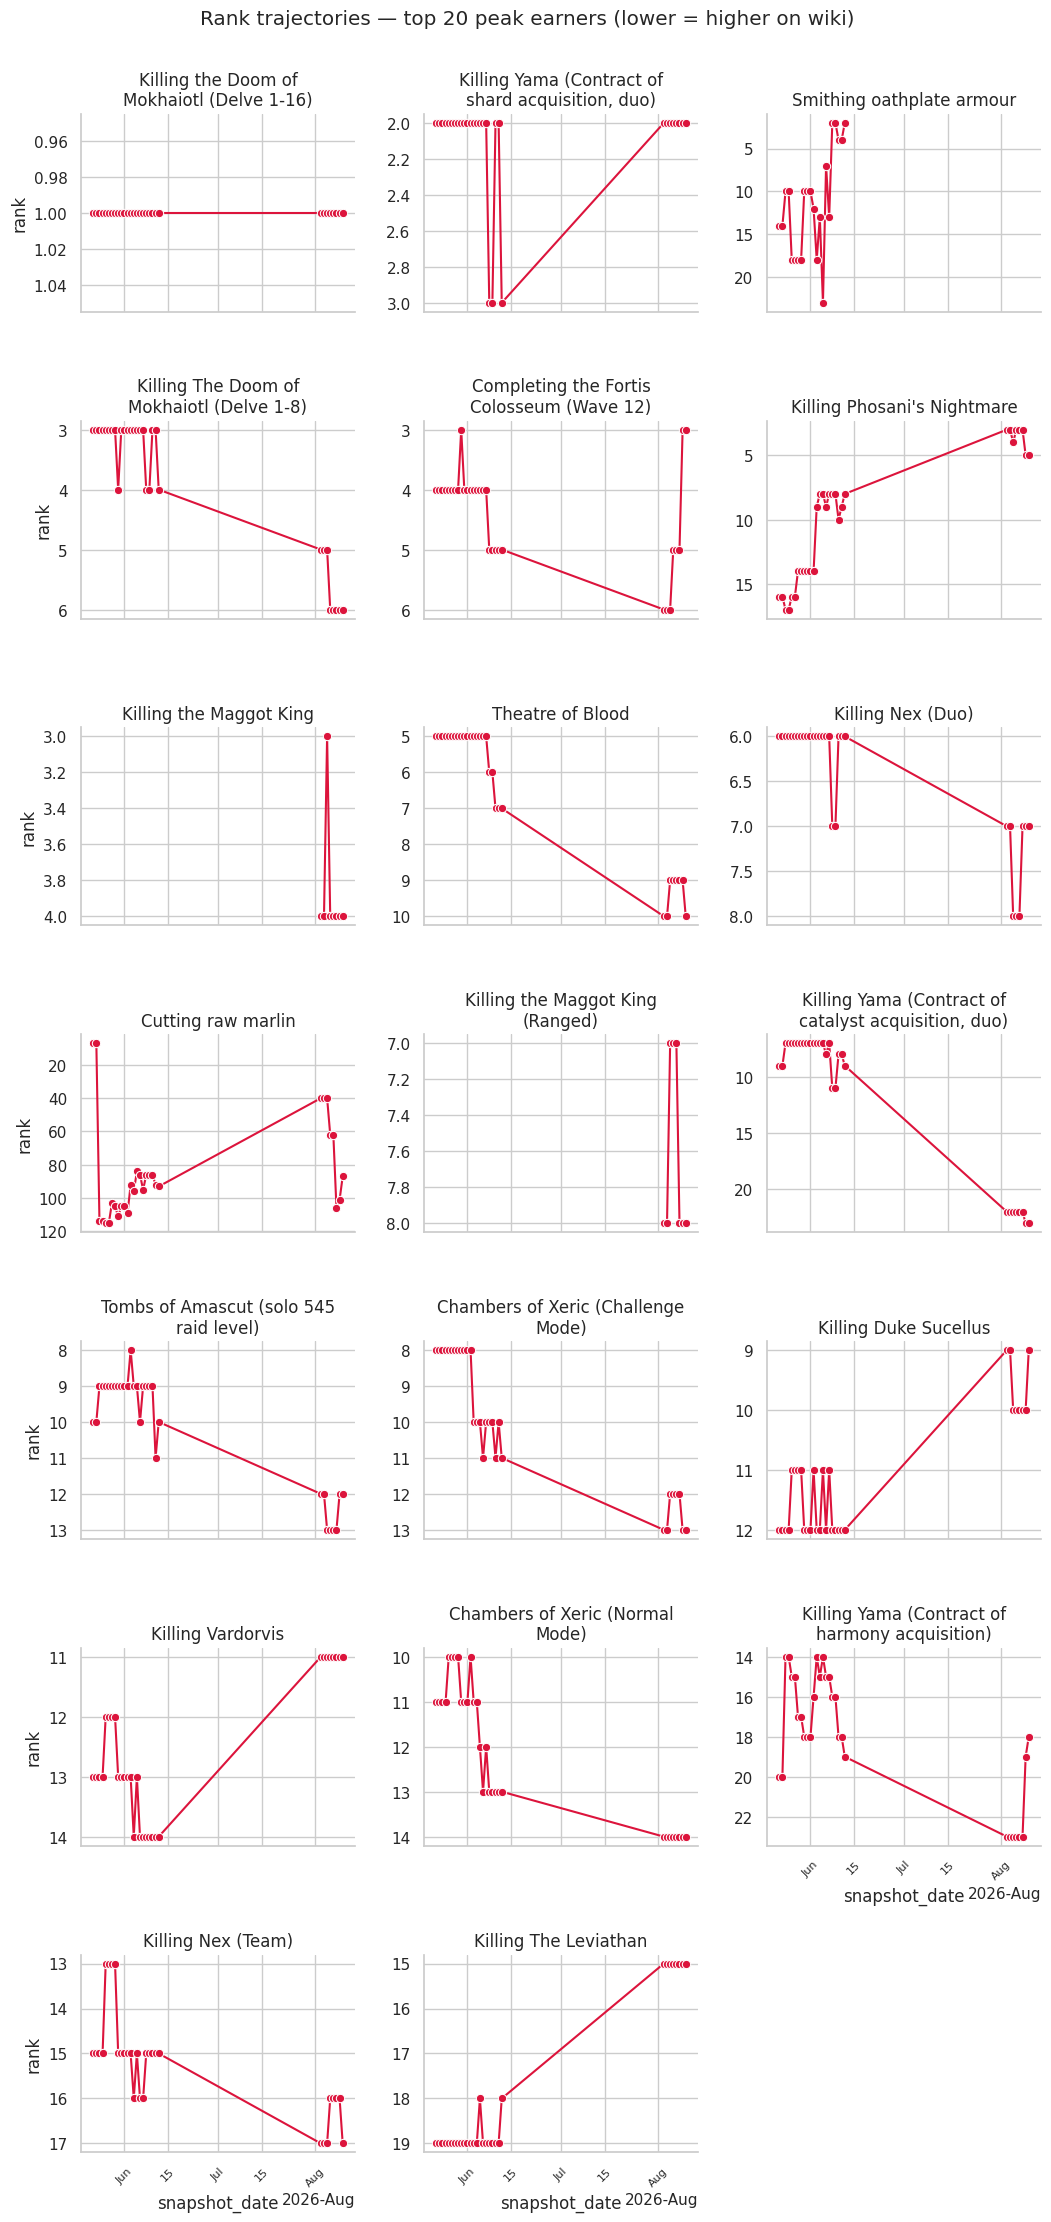

In [5]:
latest_date = panel["snapshot_date"].max()
latest_board = (
    panel.loc[panel["snapshot_date"] == latest_date]
    .sort_values("rank")
    .head(TOP_RANK_BOARD)[
        [
            "method_id",
            "rank",
            "method_name",
            "money_maker_type",
            "secondary_category",
            "intensity",
            "hourly_profit_gp",
            "gp_per_completion",
            "completions_per_hour",
            "is_members",
        ]
    ]
    .reset_index(drop=True)
)
print(f"Top {TOP_RANK_BOARD} methods on {latest_date.date()} (wiki rank):")
display(latest_board.style.format(
    {
        "hourly_profit_gp": "{:,.0f}",
        "gp_per_completion": "{:,.0f}",
        "completions_per_hour": "{:,.1f}",
    }
))

lifecycle = (
    panel.groupby("method_id", as_index=False)
    .agg(
        method_name=("method_name", "first"),
        money_maker_type=("money_maker_type", "first"),
        primary_category=("primary_category", "first"),
        secondary_category=("secondary_category", "first"),
        first_date=("snapshot_date", "min"),
        last_date=("snapshot_date", "max"),
        days_seen=("snapshot_date", "nunique"),
        first_rank=("rank", "first"),
        last_rank=("rank", "last"),
        best_rank=("rank", "min"),
        first_hourly_profit=("hourly_profit_gp", "first"),
        last_hourly_profit=("hourly_profit_gp", "last"),
        peak_hourly_profit=("hourly_profit_gp", "max"),
        median_hourly_profit=("hourly_profit_gp", "median"),
        max_single_day_gain=("hourly_profit_delta", "max"),
        max_rank_climb=("rank_improvement", "max"),
    )
)
lifecycle["total_profit_gain"] = lifecycle["last_hourly_profit"] - lifecycle["first_hourly_profit"]
lifecycle["net_rank_move"] = lifecycle["first_rank"] - lifecycle["last_rank"]

top_surges = transitions.nlargest(TOP_TABLE, "hourly_profit_delta")[
    [
        "snapshot_date",
        "method_name",
        "money_maker_type",
        "rank",
        "hourly_profit_gp",
        "hourly_profit_delta",
        "rank_improvement",
        "gp_per_completion_delta",
    ]
].reset_index(drop=True)
print(f"Top {TOP_TABLE} single-day hourly profit surges:")
display(top_surges.style.format(
    {
        "hourly_profit_gp": "{:,.0f}",
        "hourly_profit_delta": "{:+,.0f}",
        "gp_per_completion_delta": "{:+,.0f}",
    }
))

top_lifecycle = lifecycle.nlargest(TOP_TABLE, "total_profit_gain")[
    [
        "method_name",
        "money_maker_type",
        "days_seen",
        "first_hourly_profit",
        "last_hourly_profit",
        "total_profit_gain",
        "best_rank",
        "max_single_day_gain",
    ]
]
print(f"Top {TOP_TABLE} cumulative hourly profit gain across tracked days:")
display(top_lifecycle.style.format(
    {
        "first_hourly_profit": "{:,.0f}",
        "last_hourly_profit": "{:,.0f}",
        "total_profit_gain": "{:+,.0f}",
        "max_single_day_gain": "{:+,.0f}",
    }
))

# Top-20 by peak hourly profit (stable ordering for facets)
traj_ids = (
    lifecycle.nlargest(TOP_TRAJECTORIES, "peak_hourly_profit")["method_id"].tolist()
)
traj = panel.loc[panel["method_id"].isin(traj_ids)].copy()
name_order = (
    lifecycle.set_index("method_id")
    .loc[traj_ids, "method_name"]
    .tolist()
)
facet_labels = {name: wrap_facet_title(name) for name in name_order}
traj["facet_name"] = pd.Categorical(
    traj["method_name"].map(facet_labels),
    categories=[facet_labels[n] for n in name_order],
    ordered=True,
)

g = sns.FacetGrid(
    traj,
    col="facet_name",
    col_wrap=FACET_COL_WRAP,
    height=3.1,
    aspect=1.15,
    sharex=True,
    sharey=False,
)
g.map_dataframe(sns.lineplot, x="snapshot_date", y="hourly_profit_m", marker="o")
style_facet_dates(g)
g.set_axis_labels("snapshot_date", "hourly_profit_m")
g.set_titles(col_template="{col_name}")
g.fig.suptitle(f"Hourly profit trajectories — top {TOP_TRAJECTORIES} peak earners", y=1.02)
g.fig.subplots_adjust(hspace=0.55, wspace=0.25)
plt.show()

g2 = sns.FacetGrid(
    traj,
    col="facet_name",
    col_wrap=FACET_COL_WRAP,
    height=3.1,
    aspect=1.15,
    sharex=True,
    sharey=False,
)
g2.map_dataframe(sns.lineplot, x="snapshot_date", y="rank", marker="o", color="crimson")
for ax in g2.axes.flat:
    if ax.has_data():
        ax.invert_yaxis()
style_facet_dates(g2)
g2.set_axis_labels("snapshot_date", "rank")
g2.set_titles(col_template="{col_name}")
g2.fig.suptitle(
    f"Rank trajectories — top {TOP_TRAJECTORIES} peak earners (lower = higher on wiki)",
    y=1.02,
)
g2.fig.subplots_adjust(hspace=0.55, wspace=0.25)
plt.show()

# Interactive overlay: click legend to isolate methods
traj_plotly = traj.sort_values(["method_name", "snapshot_date"]).copy()
fig_top = px.line(
    traj_plotly,
    x="snapshot_date",
    y="hourly_profit_m",
    color="method_name",
    markers=True,
    title=f"Top {TOP_TRAJECTORIES} peak earners — hourly profit (interactive legend)",
    labels={
        "snapshot_date": "snapshot date",
        "hourly_profit_m": "hourly profit (M GP)",
        "method_name": "money maker",
    },
)
fig_top.update_layout(
    height=560,
    legend=dict(orientation="v", yanchor="top", y=1, xanchor="left", x=1.02),
    margin=dict(r=260),
)
show_plotly(fig_top)


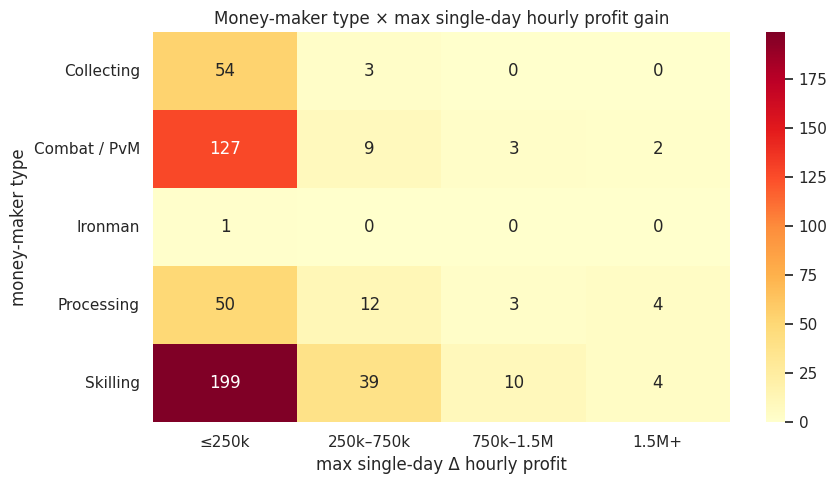

Median hourly profit (GP) by money-maker type × intensity:


intensity,High,Low,Medium,Moderate
money_maker_type,,,,
Collecting,"153,000","224,000",nan,"201,500"
Combat / PvM,"3,569,500","332,000","2,223,000","530,500"
Ironman,nan,nan,nan,"1,027,000"
Processing,"1,222,000","714,000",nan,"621,000"
Skilling,"773,000","231,000",nan,"584,500"


Money-maker type snapshot:


,money_maker_type,methods,median_hourly_profit,p90_hourly_profit,median_rank,share_of_rows
1,Combat / PvM,141,"1,510,000","7,059,600",104,27.7%
2,Ironman,1,"1,027,000","1,029,100",148,0.2%
3,Processing,69,"748,000","1,604,000",199,13.4%
4,Skilling,252,"403,000","1,602,000",279,47.5%
0,Collecting,57,"198,000","817,000",369,11.2%


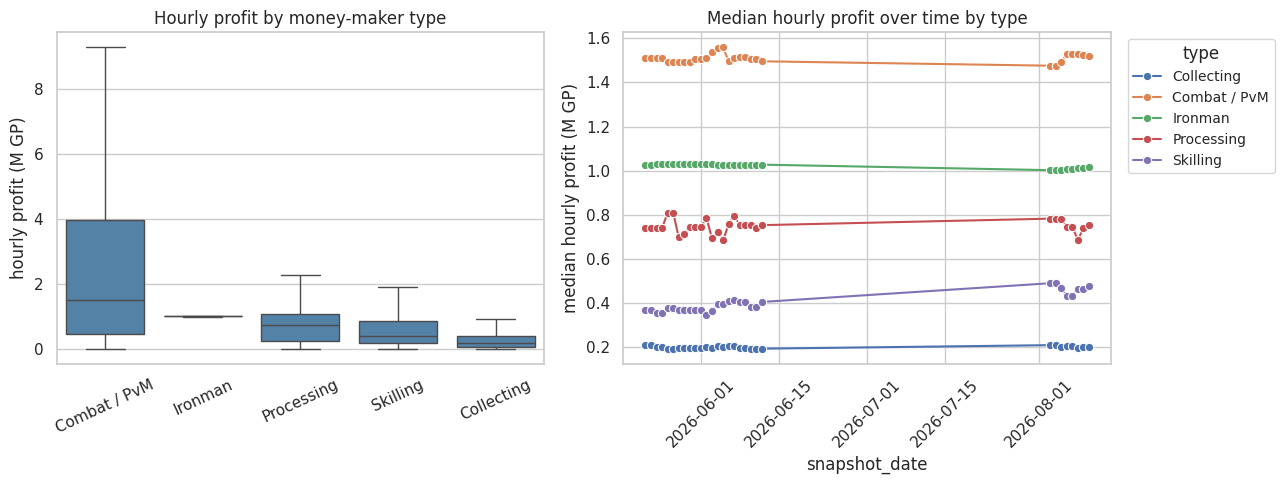

Skilling — median hourly profit by skill:


,secondary_category,methods,median_hourly_profit,best_rank
15,—,3,"2,152,500",2
10,Runecraft,25,"1,208,500",25
7,Hunter,10,"905,500",75
13,Thieving,9,"798,500",27
0,Agility,7,"663,500",71
6,Herblore,34,"570,000",48
8,Magic,26,"487,000",41
5,Fletching,17,"386,000",26
11,Sailing,9,"352,000",56
12,Smithing,21,"287,500",55


Combat / PvM — median hourly profit by wiki combat tier:


,secondary_category,methods,median_hourly_profit,p90_hourly_profit,best_rank
0,High,89,"2,291,000","9,431,500",1
3,Moderate,1,"2,223,000","2,556,000",57
2,Mid,30,"517,000","1,971,000",35
1,Low,21,"196,000","1,618,500",24


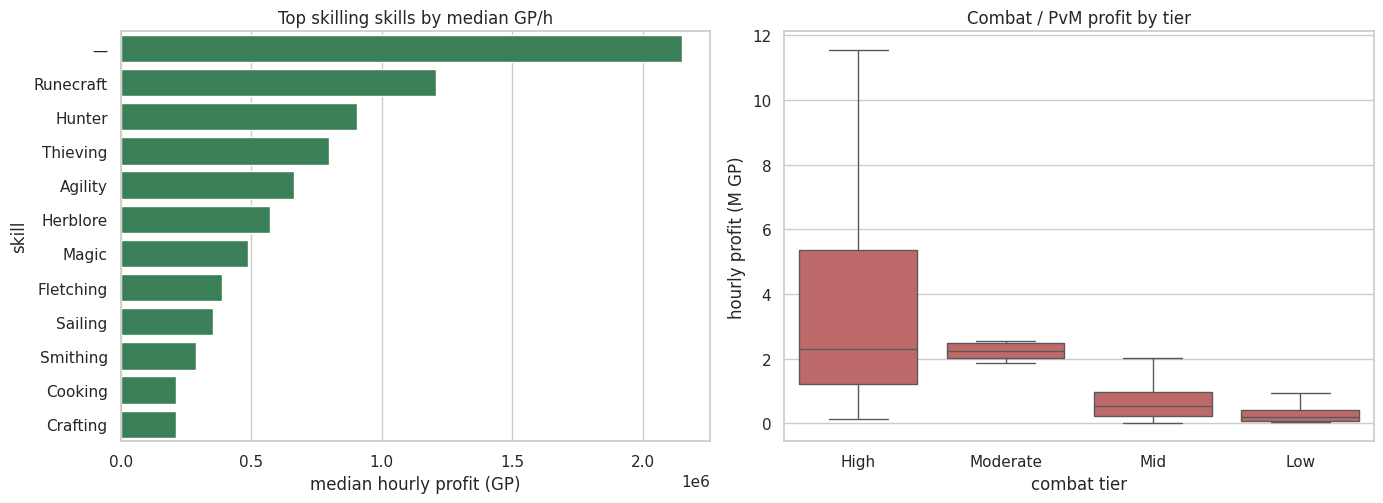

Type mix inside current top 20:


,share,count
money_maker_type,,
Combat / PvM,100.0%,20


Type readout: Combat/PvM methods own the right tail of hourly profit and most top-20 slots, while Skilling supplies the bulk of tracked methods at lower median GP/h. Processing and Collecting sit between — fewer methods, but occasional high-intensity outliers. Within Skilling, Herblore/Runecraft/Smithing usually lead median GP/h; within Combat, High-tier content dominates both median and p90 profitability.


In [6]:
cat_top = (
    lifecycle["money_maker_type"].value_counts().head(8).index.tolist()
    if lifecycle["money_maker_type"].nunique() > 8
    else lifecycle["money_maker_type"].unique().tolist()
)
lifecycle["type_top"] = lifecycle["money_maker_type"].where(
    lifecycle["money_maker_type"].isin(cat_top), other="other"
)
lifecycle["surge_bucket"] = pd.cut(
    lifecycle["max_single_day_gain"],
    bins=[-np.inf, 250_000, 750_000, 1_500_000, np.inf],
    labels=["≤250k", "250k–750k", "750k–1.5M", "1.5M+"],
)

ct = pd.crosstab(lifecycle["type_top"], lifecycle["surge_bucket"])
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(ct, annot=True, fmt="d", cmap="YlOrRd", ax=ax)
ax.set_title("Money-maker type × max single-day hourly profit gain")
ax.set_xlabel("max single-day Δ hourly profit")
ax.set_ylabel("money-maker type")
plt.tight_layout()
plt.show()

type_intensity = (
    panel.groupby(["money_maker_type", "intensity"], as_index=False)["hourly_profit_gp"]
    .median()
    .pivot(index="money_maker_type", columns="intensity", values="hourly_profit_gp")
    .sort_index()
)
print("Median hourly profit (GP) by money-maker type × intensity:")
display(type_intensity.style.format("{:,.0f}").background_gradient(cmap="YlGn", axis=None))

type_summary = (
    panel.groupby("money_maker_type", as_index=False)
    .agg(
        methods=("method_id", "nunique"),
        median_hourly_profit=("hourly_profit_gp", "median"),
        p90_hourly_profit=("hourly_profit_gp", lambda s: s.quantile(0.9)),
        median_rank=("rank", "median"),
        share_of_rows=("method_id", "size"),
    )
    .sort_values("median_hourly_profit", ascending=False)
)
type_summary["share_of_rows"] = type_summary["share_of_rows"] / type_summary["share_of_rows"].sum()
print("Money-maker type snapshot:")
display(
    type_summary.style.format(
        {
            "median_hourly_profit": "{:,.0f}",
            "p90_hourly_profit": "{:,.0f}",
            "median_rank": "{:.0f}",
            "share_of_rows": "{:.1%}",
        }
    )
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order = type_summary["money_maker_type"].tolist()
sns.boxplot(
    data=panel,
    x="money_maker_type",
    y="hourly_profit_m",
    order=order,
    showfliers=False,
    ax=axes[0],
    color="steelblue",
)
axes[0].set_title("Hourly profit by money-maker type")
axes[0].set_xlabel("")
axes[0].set_ylabel("hourly profit (M GP)")
axes[0].tick_params(axis="x", rotation=25)

type_daily = (
    panel.groupby(["snapshot_date", "money_maker_type"], as_index=False)["hourly_profit_gp"]
    .median()
)
type_daily["median_hourly_profit_m"] = type_daily["hourly_profit_gp"] / 1_000_000
sns.lineplot(
    data=type_daily,
    x="snapshot_date",
    y="median_hourly_profit_m",
    hue="money_maker_type",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Median hourly profit over time by type")
axes[1].set_ylabel("median hourly profit (M GP)")
axes[1].legend(title="type", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1].tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

# Skilling skill breakdown + Combat tier breakdown
skilling = panel.loc[panel["primary_category"] == "Skilling"].copy()
combat = panel.loc[panel["primary_category"] == "Combat"].copy()

skill_medians = (
    skilling.groupby("secondary_category", as_index=False)
    .agg(
        methods=("method_id", "nunique"),
        median_hourly_profit=("hourly_profit_gp", "median"),
        best_rank=("rank", "min"),
    )
    .sort_values("median_hourly_profit", ascending=False)
)
print("Skilling — median hourly profit by skill:")
display(
    skill_medians.style.format(
        {"median_hourly_profit": "{:,.0f}", "best_rank": "{:.0f}"}
    ).background_gradient(subset=["median_hourly_profit"], cmap="YlGn")
)

combat_medians = (
    combat.groupby("secondary_category", as_index=False)
    .agg(
        methods=("method_id", "nunique"),
        median_hourly_profit=("hourly_profit_gp", "median"),
        p90_hourly_profit=("hourly_profit_gp", lambda s: s.quantile(0.9)),
        best_rank=("rank", "min"),
    )
    .sort_values("median_hourly_profit", ascending=False)
)
print("Combat / PvM — median hourly profit by wiki combat tier:")
display(
    combat_medians.style.format(
        {
            "median_hourly_profit": "{:,.0f}",
            "p90_hourly_profit": "{:,.0f}",
            "best_rank": "{:.0f}",
        }
    ).background_gradient(subset=["median_hourly_profit"], cmap="OrRd")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
sns.barplot(
    data=skill_medians.head(12),
    x="median_hourly_profit",
    y="secondary_category",
    ax=axes[0],
    color="seagreen",
)
axes[0].set_title("Top skilling skills by median GP/h")
axes[0].set_xlabel("median hourly profit (GP)")
axes[0].set_ylabel("skill")

sns.boxplot(
    data=combat,
    x="secondary_category",
    y="hourly_profit_m",
    order=combat_medians["secondary_category"].tolist(),
    showfliers=False,
    ax=axes[1],
    color="indianred",
)
axes[1].set_title("Combat / PvM profit by tier")
axes[1].set_xlabel("combat tier")
axes[1].set_ylabel("hourly profit (M GP)")
fig.tight_layout()
plt.show()

latest_type_mix = (
    latest_board["money_maker_type"].value_counts(normalize=True).rename("share").to_frame()
)
latest_type_mix["count"] = latest_board["money_maker_type"].value_counts()
print(f"Type mix inside current top {TOP_RANK_BOARD}:")
display(latest_type_mix.style.format({"share": "{:.1%}"}))

print(
    "Type readout: Combat/PvM methods own the right tail of hourly profit and most top-20 slots, "
    "while Skilling supplies the bulk of tracked methods at lower median GP/h. "
    "Processing and Collecting sit between — fewer methods, but occasional high-intensity outliers. "
    "Within Skilling, Herblore/Runecraft/Smithing usually lead median GP/h; within Combat, "
    "High-tier content dominates both median and p90 profitability."
)


## 4 — Profit drivers: GP/completion vs throughput

GP/completion vs hourly profit: Spearman rho=1.000, p=0
Completions/hour vs hourly profit: Spearman rho=-0.332, p=0


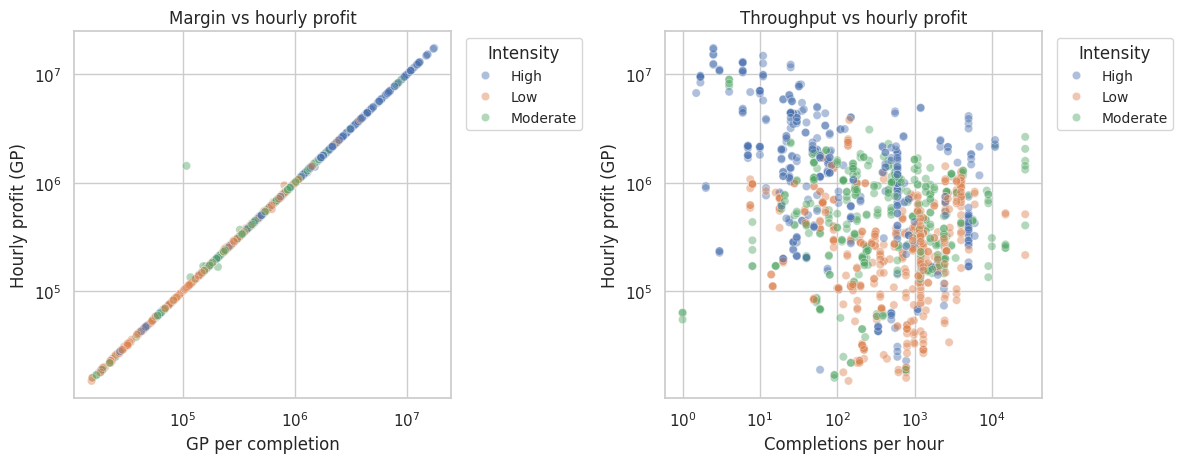

Largest single-day profit jumps — dominant driver (margin vs throughput):


,snapshot_date,method_name,hourly_profit_delta,gp_per_completion_delta,completions_per_hour_delta,profit_driver
0,2026-08-03 00:00:00,Poisoning ammunition,"+2,812,000","+2,812,000",+0.0,margin
1,2026-08-09 00:00:00,Poisoning ammunition,"+2,790,000","+2,790,000",+0.0,margin
2,2026-06-03 00:00:00,Killing Phosani's Nightmare,"+2,406,000","+2,406,412",+2.5,margin
3,2026-08-03 00:00:00,Killing Phosani's Nightmare,"+2,227,000","+2,226,619",+0.0,margin
4,2026-05-24 00:00:00,Crafting aether runes using scarred extract,"+2,749,000","+2,749,507",+0.0,margin
5,2026-06-07 00:00:00,Fletching gem-tipped dragon bolts,"+2,241,000","+2,241,000",+0.0,margin
6,2026-06-10 00:00:00,Fletching gem-tipped dragon bolts,"+3,510,000",+0,+0.0,margin
7,2026-05-29 00:00:00,Creating crystal keys,"+3,040,000","+3,040,000",+0.0,margin
8,2026-08-06 00:00:00,Creating crystal keys,"+3,245,000","+3,245,000",+0.0,margin
9,2026-05-30 00:00:00,Smithing oathplate armour,"+2,619,000","+2,619,308",+0.0,margin


In [7]:
panel["implied_hourly_profit"] = panel["gp_per_completion"] * panel["completions_per_hour"]
panel["throughput_share"] = panel["completions_per_hour"] / panel.groupby("snapshot_date")[
    "completions_per_hour"
].transform("max")

driver_sample = panel.dropna(subset=["hourly_profit_gp", "gp_per_completion", "completions_per_hour"])
rho_gp, p_gp = stats.spearmanr(driver_sample["gp_per_completion"], driver_sample["hourly_profit_gp"])
rho_kph, p_kph = stats.spearmanr(driver_sample["completions_per_hour"], driver_sample["hourly_profit_gp"])
print(f"GP/completion vs hourly profit: Spearman rho={rho_gp:.3f}, p={p_gp:.4g}")
print(f"Completions/hour vs hourly profit: Spearman rho={rho_kph:.3f}, p={p_kph:.4g}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
sns.scatterplot(
    data=driver_sample.sample(min(1200, len(driver_sample)), random_state=3),
    x="gp_per_completion",
    y="hourly_profit_gp",
    hue="intensity",
    alpha=0.45,
    ax=axes[0],
)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("GP per completion")
axes[0].set_ylabel("Hourly profit (GP)")
axes[0].set_title("Margin vs hourly profit")
axes[0].legend(title="Intensity", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.scatterplot(
    data=driver_sample.sample(min(1200, len(driver_sample)), random_state=3),
    x="completions_per_hour",
    y="hourly_profit_gp",
    hue="intensity",
    alpha=0.45,
    ax=axes[1],
)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Completions per hour")
axes[1].set_ylabel("Hourly profit (GP)")
axes[1].set_title("Throughput vs hourly profit")
axes[1].legend(title="Intensity", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

top_movers = transitions.nlargest(TOP_TABLE, "hourly_profit_delta")[["method_id", "snapshot_date"]]
mover_panel = panel.merge(top_movers, on=["method_id", "snapshot_date"])
mover_panel["profit_driver"] = np.where(
    mover_panel["gp_per_completion_delta"].abs() >= mover_panel["completions_per_hour_delta"].abs(),
    "margin",
    "throughput",
)
print("Largest single-day profit jumps — dominant driver (margin vs throughput):")
display(
    mover_panel[
        [
            "snapshot_date",
            "method_name",
            "hourly_profit_delta",
            "gp_per_completion_delta",
            "completions_per_hour_delta",
            "profit_driver",
        ]
    ].style.format(
        {
            "hourly_profit_delta": "{:+,.0f}",
            "gp_per_completion_delta": "{:+,.0f}",
            "completions_per_hour_delta": "{:+,.1f}",
        }
    )
)

## 5 — Raids: input cost vs output value

For raid / raid-like methods (CoX, ToB, ToA, Colosseum, Nightmare, Gauntlet, Moons), value each input and output line as `qty_per_completion × GE median price` on every snapshot day. Compare **supply cost**, **loot value**, and **net margin** over time.


Raid I/O economics on 2026-08-10 (GP per completion):


io_type,method_name,input,output,net_value_gp,input_share
0,Chambers of Xeric (Challenge Mode),"35,032","5,208,895","+5,173,863",0.7%
1,Completing the Fortis Colosseum (Wave 12),"186,805","3,055,472","+2,868,667",6.1%
2,Chambers of Xeric (Normal Mode),"132,407","2,785,781","+2,653,374",4.8%
3,Tombs of Amascut (solo 545 raid level),"71,866","1,415,699","+1,343,833",5.1%
4,Killing Phosani's Nightmare,"11,347","1,279,541","+1,268,194",0.9%
5,Tombs of Amascut (solo 450 raid level),0,"1,185,936","+1,185,936",0.0%
6,Theatre of Blood,"49,778","1,030,247","+980,470",4.8%
7,Tombs of Amascut (Expert),"145,576","892,861","+747,285",16.3%
8,Completing The Corrupted Gauntlet,0,"555,552","+555,552",0.0%
9,Killing The Nightmare,"14,184","436,304","+422,121",3.3%


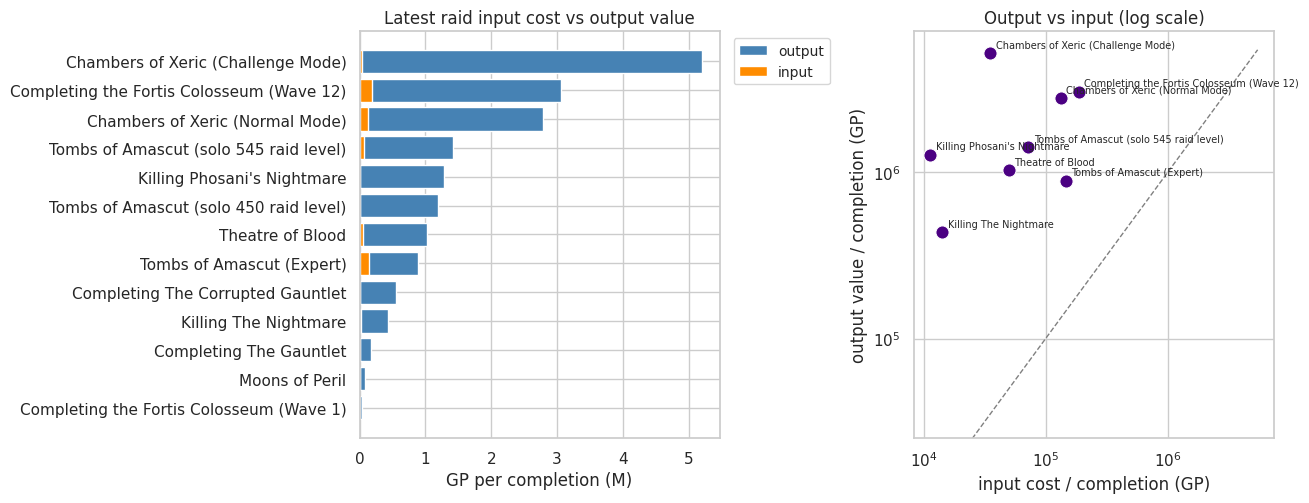

Raid readout: output loot value usually dwarfs supply cost, so net margin tracks output price moves more than input spikes. Methods with non-trivial input shares (potions, thralls, supplies) are more exposed when consumable prices climb; zero-input setups (Gauntlet, some ToA variants) are pure loot-price bets.


In [8]:
raid_methods = methods.loc[
    methods["method_name"].str.contains(RAID_NAME_PATTERN, case=False, na=False),
    ["method_id", "method_name", "categories", "intensity"],
].copy()
assert not raid_methods.empty, "no raid-like methods matched RAID_NAME_PATTERN"
raid_methods["money_maker_type"] = raid_methods["categories"].map(primary_category).replace(
    {"Combat": "Combat / PvM"}
)

price_med = (
    prices.loc[prices["metric"] == "price_p50", ["item_id", "snapshot_date", "value"]]
    .rename(columns={"value": "price_p50"})
    .copy()
)
price_med["item_id"] = price_med["item_id"].astype(int)

raid_io = (
    io_lines.dropna(subset=["item_id"])
    .loc[lambda d: d["method_id"].isin(raid_methods["method_id"])]
    .copy()
)
raid_io["item_id"] = raid_io["item_id"].astype(int)
raid_io = raid_io.merge(raid_methods[["method_id", "method_name"]], on="method_id", how="left")
raid_io = raid_io.merge(price_med, on="item_id", how="inner")
raid_io["line_value_gp"] = raid_io["qty_per_completion"] * raid_io["price_p50"]

raid_io_daily = (
    raid_io.groupby(["method_id", "method_name", "snapshot_date", "io_type"], as_index=False)[
        "line_value_gp"
    ]
    .sum()
)
raid_margin = (
    raid_io_daily.pivot_table(
        index=["method_id", "method_name", "snapshot_date"],
        columns="io_type",
        values="line_value_gp",
        aggfunc="sum",
    )
    .reset_index()
    .fillna(0.0)
)
assert {"input", "output"}.issubset(raid_margin.columns), raid_margin.columns.tolist()
raid_margin["net_value_gp"] = raid_margin["output"] - raid_margin["input"]
raid_margin["input_share"] = np.where(
    raid_margin["output"] > 0,
    raid_margin["input"] / raid_margin["output"],
    np.nan,
)

latest_raid = raid_margin.loc[raid_margin["snapshot_date"] == raid_margin["snapshot_date"].max()].copy()
latest_raid = latest_raid.sort_values("net_value_gp", ascending=False)
print(f"Raid I/O economics on {latest_raid['snapshot_date'].iloc[0].date()} (GP per completion):")
display(
    latest_raid[["method_name", "input", "output", "net_value_gp", "input_share"]]
    .reset_index(drop=True)
    .style.format(
        {
            "input": "{:,.0f}",
            "output": "{:,.0f}",
            "net_value_gp": "{:+,.0f}",
            "input_share": "{:.1%}",
        }
    )
    .background_gradient(subset=["net_value_gp"], cmap="YlGn")
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
plot_latest = latest_raid.sort_values("output", ascending=True)
axes[0].barh(plot_latest["method_name"], plot_latest["output"] / 1_000_000, color="steelblue", label="output")
axes[0].barh(plot_latest["method_name"], plot_latest["input"] / 1_000_000, color="darkorange", label="input")
axes[0].set_xlabel("GP per completion (M)")
axes[0].set_title("Latest raid input cost vs output value")
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left")

sns.scatterplot(
    data=latest_raid,
    x="input",
    y="output",
    s=90,
    ax=axes[1],
    color="indigo",
)
for _, row in latest_raid.iterrows():
    axes[1].annotate(
        wrap_facet_title(row["method_name"], width=22).replace(chr(10), " "),
        (row["input"], row["output"]),
        fontsize=7,
        xytext=(4, 4),
        textcoords="offset points",
    )
max_xy = max(latest_raid["input"].max(), latest_raid["output"].max()) * 1.05
axes[1].plot([0, max_xy], [0, max_xy], ls="--", c="grey", lw=1)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("input cost / completion (GP)")
axes[1].set_ylabel("output value / completion (GP)")
axes[1].set_title("Output vs input (log scale)")
fig.tight_layout()
plt.show()

raid_margin_long = raid_margin.melt(
    id_vars=["method_id", "method_name", "snapshot_date"],
    value_vars=["input", "output", "net_value_gp"],
    var_name="metric",
    value_name="gp_per_completion",
)
fig_raid = px.line(
    raid_margin_long,
    x="snapshot_date",
    y="gp_per_completion",
    color="method_name",
    line_dash="metric",
    markers=True,
    title="Raid input / output / net value over time (legend filter)",
    labels={
        "snapshot_date": "snapshot date",
        "gp_per_completion": "GP per completion",
        "method_name": "raid",
        "metric": "dimension",
    },
)
fig_raid.update_layout(
    height=560,
    legend=dict(orientation="v", yanchor="top", y=1, xanchor="left", x=1.02),
    margin=dict(r=280),
)
show_plotly(fig_raid)

print(
    "Raid readout: output loot value usually dwarfs supply cost, so net margin tracks output price "
    "moves more than input spikes. Methods with non-trivial input shares (potions, thralls, supplies) "
    "are more exposed when consumable prices climb; zero-input setups (Gauntlet, some ToA variants) "
    "are pure loot-price bets."
)


## 6 — GE item explorer for raids (interactive)

Use the dropdown to choose a **raid** and an **item** (or all items / I/O costs only). Single-item views still include the raid **input cost** and **output value** totals. Legend clicks further isolate series.


In [9]:
io_prices = io_lines.dropna(subset=["item_id"]).copy()
io_prices["item_id"] = io_prices["item_id"].astype(int)

price_long = prices.loc[prices["metric"].isin(["price_p50", "price_variance", "volume"])].copy()
price_wide = (
    price_long.pivot_table(
        index=["item_id", "snapshot_date"],
        columns="metric",
        values="value",
        aggfunc="first",
    )
    .reset_index()
    .sort_values(["item_id", "snapshot_date"])
)
price_wide["price_p50_delta"] = price_wide.groupby("item_id")["price_p50"].diff()

io_price = io_prices.merge(price_wide, on="item_id", how="inner", validate="m:m")
io_price = io_price.merge(
    methods[["method_id", "method_name"]], on="method_id", how="left", validate="m:1"
)

surge_keys = transitions.nlargest(TOP_TABLE, "hourly_profit_delta")[["method_id", "snapshot_date"]]
surge_items = io_price.merge(surge_keys, on=["method_id", "snapshot_date"])
surge_items["signed_price_delta"] = np.where(
    surge_items["io_type"] == "input",
    -surge_items["price_p50_delta"],
    surge_items["price_p50_delta"],
)
surge_items["profit_impact_proxy"] = surge_items["signed_price_delta"] * surge_items["qty_per_completion"]

item_moves = (
    surge_items.groupby(
        ["snapshot_date", "method_name", "item_name", "io_type"], as_index=False
    )
    .agg(
        qty_per_completion=("qty_per_completion", "first"),
        price_p50=("price_p50", "first"),
        price_p50_delta=("price_p50_delta", "first"),
        profit_impact_proxy=("profit_impact_proxy", "first"),
        price_variance=("price_variance", "first"),
        volume=("volume", "first"),
    )
    .sort_values("profit_impact_proxy", ascending=False)
)
print("Item price moves on the biggest method profit surge days (signed by I/O type):")
display(
    item_moves.head(TOP_TABLE).style.format(
        {
            "qty_per_completion": "{:,.3f}",
            "price_p50": "{:,.0f}",
            "price_p50_delta": "{:+,.0f}",
            "profit_impact_proxy": "{:+,.0f}",
            "price_variance": "{:,.0f}",
            "volume": "{:,.0f}",
        }
    )
)

top_board_ids = latest_board["method_id"].tolist()
board_items = io_price.loc[io_price["method_id"].isin(top_board_ids)].copy()
vol_summary = (
    board_items.groupby(["method_name", "item_name", "io_type"], as_index=False)
    .agg(
        median_variance=("price_variance", "median"),
        median_volume=("volume", "median"),
        median_price=("price_p50", "median"),
    )
    .sort_values("median_variance", ascending=False)
)
print(f"Highest median GE price variance among items in the current top {TOP_RANK_BOARD}:")
display(
    vol_summary.head(TOP_TABLE).style.format(
        {
            "median_variance": "{:,.0f}",
            "median_volume": "{:,.0f}",
            "median_price": "{:,.0f}",
        }
    )
)

# --- Interactive raid × item explorer (Plotly dropdown; Kaggle-safe) ---
raid_item_prices = raid_io.copy()
raid_item_prices["series_kind"] = "item"
raid_item_prices["series_name"] = (
    raid_item_prices["io_type"] + ": " + raid_item_prices["item_name"]
)
raid_item_prices["y_value"] = raid_item_prices["price_p50"]

cost_series = raid_margin.melt(
    id_vars=["method_id", "method_name", "snapshot_date"],
    value_vars=["input", "output"],
    var_name="io_type",
    value_name="y_value",
)
cost_series["series_kind"] = "aggregate"
cost_series["series_name"] = np.where(
    cost_series["io_type"] == "input",
    "INPUT COST (total / completion)",
    "OUTPUT VALUE (total / completion)",
)
cost_series["item_name"] = cost_series["series_name"]

explorer_cols = [
    "method_id",
    "method_name",
    "snapshot_date",
    "io_type",
    "item_name",
    "series_name",
    "series_kind",
    "y_value",
]
explorer = pd.concat(
    [raid_item_prices[explorer_cols], cost_series[explorer_cols]],
    ignore_index=True,
).sort_values(["method_name", "series_kind", "series_name", "snapshot_date"])

raid_names = sorted(explorer["method_name"].unique())
assert raid_names, "raid explorer has no methods"
default_raid = next(
    (n for n in raid_names if "Phosani" in n),
    next((n for n in raid_names if "Nightmare" in n), raid_names[0]),
)
default_mode = "ALL"
default_item = None
# Prefer Harmonised orb on Phosani when present
harm_series = "output: Harmonised orb"
if (
    (explorer["method_name"] == default_raid)
    & (explorer["series_name"] == harm_series)
).any():
    default_mode = harm_series

fig_explore = go.Figure()
trace_meta = []  # (raid_name, series_name, is_aggregate)

for raid_name in raid_names:
    raid_df = explorer.loc[explorer["method_name"] == raid_name]
    series_order = (
        raid_df.loc[raid_df["series_kind"] == "aggregate", "series_name"].drop_duplicates().tolist()
        + raid_df.loc[raid_df["series_kind"] == "item", "series_name"].drop_duplicates().tolist()
    )
    for series_name in series_order:
        s = raid_df.loc[raid_df["series_name"] == series_name].sort_values("snapshot_date")
        is_agg = bool((s["series_kind"] == "aggregate").iloc[0])
        fig_explore.add_trace(
            go.Scatter(
                x=s["snapshot_date"],
                y=s["y_value"],
                mode="lines+markers",
                name=series_name,
                legendgroup=series_name,
                visible=False,
                hovertemplate=(
                    f"{raid_name}<br>%{{x|%Y-%m-%d}}<br>{series_name}: %{{y:,.0f}}<extra></extra>"
                ),
                line=dict(width=3 if is_agg else 1.5),
            )
        )
        trace_meta.append((raid_name, series_name, is_agg))

n_traces = len(trace_meta)


def visibility_for(raid_name: str, item_mode: str) -> list[bool]:
    flags = []
    for r_name, series_name, is_agg in trace_meta:
        if r_name != raid_name:
            flags.append(False)
        elif item_mode == "ALL":
            flags.append(True)
        elif item_mode == "COSTS":
            flags.append(is_agg)
        else:
            # single item still keeps I/O cost dimension visible
            flags.append(is_agg or series_name == item_mode)
    assert len(flags) == n_traces
    return flags


def title_for(raid_name: str, item_mode: str) -> str:
    if item_mode == "ALL":
        return f"{raid_name} — all items + input/output costs"
    if item_mode == "COSTS":
        return f"{raid_name} — input cost vs output value"
    return f"{raid_name} — {item_mode} (+ I/O costs)"


def title_annotation(text: str) -> dict:
    return dict(
        text=text,
        x=0.0,
        xref="paper",
        y=1.06,
        yref="paper",
        showarrow=False,
        xanchor="left",
        yanchor="bottom",
        font=dict(size=14, color="#333333"),
    )


buttons = []
default_active = 0
for raid_name in raid_names:
    items = (
        explorer.loc[
            (explorer["method_name"] == raid_name) & (explorer["series_kind"] == "item"),
            "series_name",
        ]
        .drop_duplicates()
        .tolist()
    )
    # Keep dropdown usable: all/costs + rare/high-value-looking outputs + any Harmonised
    rich_items = [
        name
        for name in items
        if name.startswith("output:")
        and (
            "orb" in name.lower()
            or "kit" in name.lower()
            or "tasset" in name.lower()
            or "ancestral" in name.lower()
            or "shadow" in name.lower()
            or "fang" in name.lower()
            or "masori" in name.lower()
            or "twisted" in name.lower()
            or "scythe" in name.lower()
            or "avernic" in name.lower()
            or "unique" in name.lower()
            or name == harm_series
        )
    ]
    # Always allow every input item (usually few) plus a capped set of outputs
    input_items = [name for name in items if name.startswith("input:")]
    other_outputs = [name for name in items if name.startswith("output:") and name not in rich_items]
    # include top remaining outputs by median line value if available
    ranked = (
        raid_io.loc[raid_io["method_name"] == raid_name]
        .groupby("item_name", as_index=False)["line_value_gp"]
        .median()
        .sort_values("line_value_gp", ascending=False)
    )
    top_output_names = set(ranked["item_name"].head(8))
    top_outputs = [
        name
        for name in other_outputs
        if name.replace("output: ", "", 1) in top_output_names
    ]
    item_modes = (
        [("All items + I/O costs", "ALL"), ("I/O costs only", "COSTS")]
        + [(name[:55], name) for name in input_items + rich_items + top_outputs]
    )
    # de-dupe labels while preserving order
    seen = set()
    ordered_modes = []
    for label, mode in item_modes:
        if mode in seen:
            continue
        seen.add(mode)
        ordered_modes.append((label, mode))

    for label, mode in ordered_modes:
        btn_label = f"{raid_name[:34]} · {label}"
        if raid_name == default_raid and mode == default_mode:
            default_active = len(buttons)
        buttons.append(
            {
                "label": btn_label[:70],
                "method": "update",
                "args": [
                    {"visible": visibility_for(raid_name, mode)},
                    {"annotations": [title_annotation(title_for(raid_name, mode))]},
                ],
            }
        )

assert buttons, "no explorer buttons"
for i, (raid_name, series_name, is_agg) in enumerate(trace_meta):
    fig_explore.data[i].visible = visibility_for(default_raid, default_mode)[i]

fig_explore.update_layout(
    title=None,
    height=640,
    xaxis_title="snapshot date",
    yaxis_title="GP (unit price or per-completion total)",
    legend=dict(orientation="v", yanchor="top", y=1, xanchor="left", x=1.02),
    margin=dict(t=110, r=320, l=60),
    updatemenus=[
        {
            "buttons": buttons,
            "direction": "down",
            "showactive": True,
            "x": 0.0,
            "xanchor": "left",
            "y": 1.16,
            "yanchor": "top",
            "active": default_active,
            "pad": {"r": 10, "t": 0},
            "bgcolor": "white",
        }
    ],
    annotations=[title_annotation(title_for(default_raid, default_mode))],
)
show_plotly(fig_explore)


Item price moves on the biggest method profit surge days (signed by I/O type):


,snapshot_date,method_name,item_name,io_type,qty_per_completion,price_p50,price_p50_delta,profit_impact_proxy,price_variance,volume
10,2026-05-30 00:00:00,Smithing oathplate armour,Oathplate legs,output,1.000,"90,151,473","+591,060","+591,060","162,312,771,860",435
53,2026-06-08 00:00:00,Smithing oathplate armour,Oathplate chest,output,1.000,"92,180,497","+563,636","+563,636","836,393,169,977",530
45,2026-06-06 00:00:00,Smithing oathplate armour,Oathplate shards,input,450.000,"192,552",-610,"+274,612","410,471","29,701"
54,2026-06-08 00:00:00,Smithing oathplate armour,Oathplate legs,output,1.000,"91,830,584","+264,892","+264,892","606,985,561,235",460
9,2026-05-30 00:00:00,Smithing oathplate armour,Oathplate chest,output,1.000,"90,467,723","+149,976","+149,976","238,131,840,388",450
75,2026-08-03 00:00:00,Killing Phosani's Nightmare,Harmonised orb,output,0.001,"416,565,046","+205,260,062","+128,288","118,706,010,038,169",213
55,2026-06-08 00:00:00,Smithing oathplate armour,Oathplate shards,input,450.000,"191,302",-279,"+125,550","1,346,334","43,050"
79,2026-08-03 00:00:00,Killing Phosani's Nightmare,Inquisitor's plateskirt,output,0.001,"146,010,994","+52,310,994","+74,730","2,521,314,796,409",235
77,2026-08-03 00:00:00,Killing Phosani's Nightmare,Inquisitor's hauberk,output,0.001,"132,394,300","+25,144,300","+35,920","2,783,088,104,426",221
76,2026-08-03 00:00:00,Killing Phosani's Nightmare,Inquisitor's great helm,output,0.001,"87,537,639","+23,569,704","+33,671","1,094,069,744,401",201


Highest median GE price variance among items in the current top 20:


,method_name,item_name,io_type,median_variance,median_volume,median_price
49,Chambers of Xeric (Challenge Mode),Twisted bow,output,"7,025,681,403,490",244,"1,555,586,501"
105,Chambers of Xeric (Normal Mode),Twisted bow,output,"7,025,681,403,490",244,"1,555,586,501"
293,Killing Phosani's Nightmare,Harmonised orb,output,"7,024,203,666,587",70,"233,805,385"
289,Killing Phosani's Nightmare,Eldritch orb,output,"5,690,015,616,073",100,"192,931,640"
296,Killing Phosani's Nightmare,Inquisitor's mace,output,"5,192,746,746,174",158,"330,817,707"
214,Killing Nex (Team),Nihil horn,output,"1,907,365,564,127",22,"320,817,975"
187,Killing Nex (Duo),Nihil horn,output,"1,907,365,564,127",22,"320,817,975"
297,Killing Phosani's Nightmare,Inquisitor's plateskirt,output,"1,469,366,770,466",131,"94,000,294"
313,Killing The Doom of Mokhaiotl (Delve 1-8),Avernic treads,output,"1,141,640,187,572",490,"176,428,577"
480,Killing the Doom of Mokhaiotl (Delve 1-16),Avernic treads,output,"1,141,640,187,572",490,"176,428,577"


In [10]:
big_surge = transitions.loc[transitions["hourly_profit_delta"] >= 1_500_000]
surge_by_day = (
    transitions.groupby("snapshot_date")
    .agg(
        transitions=("method_id", "count"),
        median_gain=("hourly_profit_delta", "median"),
        big_surges=("hourly_profit_delta", lambda s: (s >= 1_500_000).sum()),
    )
    .reset_index()
)

stable_top = (
    panel.loc[panel["rank"] <= TOP_RANK_BOARD]
    .groupby("method_id")
    .agg(
        days_in_top=("snapshot_date", "nunique"),
        avg_rank=("rank", "mean"),
        method_name=("method_name", "first"),
        money_maker_type=("money_maker_type", "first"),
    )
    .sort_values(["days_in_top", "avg_rank"], ascending=[False, True])
)

print("=== Top money makers summary ===")
print(
    f"Daily snapshots: {panel['snapshot_date'].nunique()} days, "
    f"{methods.shape[0]:,} methods in entity table"
)
print(
    f"Methods tracked 2+ days: {(days_on_board >= 2).sum():,} "
    f"({(days_on_board >= 2).mean() * 100:.1f}% of seen methods)"
)
print(f"Day-over-day transitions: {len(transitions):,}")
print(
    f"Transitions with ≥1.5M GP/h profit gain: {len(big_surge):,} "
    f"({len(big_surge) / len(transitions) * 100:.2f}%)"
)
print(f"Median Δ hourly profit on transition days: {transitions['hourly_profit_delta'].median():,.0f} GP")
print(f"Median rank improvement: {transitions['rank_improvement'].median():.0f} positions")
print()
print(f"Current #1 method ({latest_date.date()}):")
leader = latest_board.iloc[0]
print(
    f"  {leader['method_name']}\n"
    f"  {leader['hourly_profit_gp']:,.0f} GP/h | rank #{leader['rank']:.0f} | "
    f"{leader['money_maker_type']} | "
    f"{leader['gp_per_completion']:,.0f} GP/completion × {leader['completions_per_hour']:.1f}/h"
)
print()
print(f"Most persistent top-{TOP_RANK_BOARD} methods (days spent in top ranks):")
print(stable_top.head(5).to_string(index=False))
print()
print("Busiest surge days (≥1.5M GP/h jumps):")
print(surge_by_day.sort_values("big_surges", ascending=False).head(5).to_string(index=False))
print()
print("Biggest single-day profit surge:")
row = transitions.loc[transitions["hourly_profit_delta"].idxmax()]
print(
    f"  {row['method_name']}\n"
    f"  +{row['hourly_profit_delta']:,.0f} GP/h on {row['snapshot_date'].date()}, "
    f"rank #{row['rank']:.0f}"
)
print()
print(
    "Takeaway: Combat/PvM (especially high-tier raids and bosses) dominates the top of the "
    "wiki leaderboard, while Skilling fills most of the long tail at lower median GP/h. "
    "Hourly profit moves mainly through GP/completion shifts rather than throughput tweaks. "
    "For raids, loot output value usually swamps supply input cost — so GE price moves on "
    "rare outputs explain more day-over-day swing than consumable inflation. Use the interactive "
    "raid/item explorer to isolate those price paths."
)


=== Top money makers summary ===
Daily snapshots: 30 days, 520 methods in entity table
Methods tracked 2+ days: 520 (100.0% of seen methods)
Day-over-day transitions: 14,114
Transitions with ≥1.5M GP/h profit gain: 22 (0.16%)
Median Δ hourly profit on transition days: 0 GP
Median rank improvement: -0 positions

Current #1 method (2026-08-10):
  Killing the Doom of Mokhaiotl (Delve 1-16)
  15,078,000 GP/h | rank #1 | Combat / PvM | 15,077,627 GP/completion × 2.5/h

Most persistent top-20 methods (days spent in top ranks):
 days_in_top  avg_rank                                       method_name money_maker_type
          30  1.000000        Killing the Doom of Mokhaiotl (Delve 1-16)     Combat / PvM
          30  2.100000 Killing Yama (Contract of shard acquisition, duo)     Combat / PvM
          30  3.833333         Killing The Doom of Mokhaiotl (Delve 1-8)     Combat / PvM
          30  4.366667         Completing the Fortis Colosseum (Wave 12)     Combat / PvM
          30  6.433333 